# Plot

In [106]:
from typing import List, Dict, Sequence
import itertools
import functools
import numpy as np
from tqdm import tqdm
import cirq
import qiskit
import qiskit.visualization
from qiskit.circuit.library import Barrier
import qiskit_ibm_runtime
from qiskit_ibm_runtime import SamplerV2 as Sampler

import stim
import stimcirq

import matplotlib.pyplot as plt; plt.rcParams.update({"font.family": "serif", "font.size": 12})

from encoded.diagonalize import string_to_cirq_paulistring
from encoded.tcc import get_stabilizer_generators, tcc_encoding

## Set parameters

In [2]:
import glob

import pickle

In [3]:
d = 7                                   # Code distance.
observable: str = "ZZ"                  # (Logical) observable to measure. Either XX or ZZ.

In [4]:
distance_to_nqubits = lambda d: (3 * d ** 2 + 1) // 4

n = distance_to_nqubits(d)
n

37

In [5]:
nshots_physical = 10_000

In [6]:
# Expectation of pauli on bitstring measured in diagonal basis.
def compute_expectation(
    pauli: cirq.PauliString,
    counts: Dict[str, int],
) -> float:
    if pauli is cirq.PauliString():
        return 1.0

    expectation = 0.0

    indices = [q.x for q in pauli.qubits]
    for key, value in counts.items():
        key = list(map(int, list(key[::-1])))
        expectation += (-1) ** sum([key[i] for i in indices]) * value

    return pauli.coefficient * expectation / sum(counts.values())

In [7]:
def process_logical_counts(counts, zero_bitstrings, one_bitstrings, nshots):
    expval: float = 0.0
    num_noncodewords = 0
    num00 = 0
    num01 = 0
    num10 = 0
    num11 = 0
    for bitstring, count in counts.items():
        q0 = int("".join(str(s) for s in bitstring[:n][::]), 2)  # NOTE: Endianess.
        q1 = int("".join(str(s) for s in bitstring[n:][::]), 2)  # NOTE: Endianess.
        if q0 in zero_bitstrings and q1 in zero_bitstrings:
            expval += count
            num00 += count
        elif q0 in zero_bitstrings and q1 in one_bitstrings:
            expval -= count
            num01 += count
        elif q0 in one_bitstrings and q1 in zero_bitstrings:
            expval -= count
            num10 += count
        elif q0 in one_bitstrings and q1 in one_bitstrings:
            expval += count
            num11 += count
        else:
            num_noncodewords += count
    num_codewords = nshots - num_noncodewords
    std_estimate = 1.0 / num_codewords
    postselection_rate = num_codewords / nshots
    expval /= num_codewords
    return expval, std_estimate, postselection_rate, num00, num01, num10, num11

In [8]:
zero_bitstrings = np.loadtxt(f"zero_bitstrings_d{d}.txt")
one_bitstrings = np.loadtxt(f"one_bitstrings_d{d}.txt")

In [9]:
datadirs = sorted(glob.glob(f"./v0/bell_tcc_distance_{d}*"))

depths = []
evals_raw = []
evals_encoded = []
evals_encoded_dd = []

stds_encoded = []
stds_encoded_dd = []

postselection_rates = []
postselection_rates_dd = []
all_nshots = []
for datadir in datadirs:
    depth = int(datadir[datadir.find("depth") + 6:].split("_")[0])
    all_counts_raw = pickle.load(open(f"{datadir}/all_counts_raw.pkl", "rb"))
    all_counts = pickle.load(open(f"{datadir}/all_counts.pkl", "rb"))
    all_counts_dd = pickle.load(open(f"{datadir}/all_counts_dd.pkl", "rb"))

    nshots = int(np.loadtxt(f"{datadir}/nshots.txt"))
    all_nshots.append(nshots)
    # to_run = pickle.load(open(f"{datadir}/circuit.pkl", "rb"))

    ev_physical = compute_expectation(string_to_cirq_paulistring("ZZ"), all_counts_raw[0])

    expval, std_estimate, postselection_rate, num00, num01, num10, num11 = process_logical_counts(all_counts[0], zero_bitstrings, one_bitstrings, nshots)
    expval_dd, std_estimate_dd, postselection_rate_dd, num00_dd, num01_dd, num10_dd, num11_dd = process_logical_counts(all_counts_dd[0], zero_bitstrings, one_bitstrings, nshots)

    depths.append(depth)
    evals_raw.append(np.real_if_close(ev_physical))
    evals_encoded.append(expval)
    evals_encoded_dd.append(expval_dd)

    postselection_rates.append(postselection_rate)
    postselection_rates_dd.append(postselection_rate_dd)

    stds_encoded.append(std_estimate)
    stds_encoded_dd.append(std_estimate_dd)

In [17]:
depths = np.array(depths)
evals_raw = np.array(evals_raw)
evals_encoded = np.array(evals_encoded)
evals_encoded_dd = np.array(evals_encoded_dd)

postselection_rates = np.array(postselection_rates)
postselection_rates_dd = np.array(postselection_rates_dd)

stds_encoded = np.array(stds_encoded)
stds_encoded_dd = np.array(stds_encoded_dd)

In [26]:
evals_sim = np.loadtxt(f"./sim_results/tcc_sim_depolarizing_0.001_distance_{d}_maxdepth_110_evals.txt")
stds_sim = np.loadtxt(f"./sim_results/tcc_sim_depolarizing_0.001_distance_{d}_maxdepth_110_stds.txt")
postselection_rates_sim = np.loadtxt(f"./sim_results/tcc_sim_depolarizing_0.001_distance_{d}_maxdepth_110_postselectionrates.txt")

if d == 7:
    depths = np.arange(0, 10 * len(evals_sim), 10)

evals_sim = evals_sim[:len(depths)]
stds_sim = stds_sim[:len(depths)]
postselection_rates_sim = postselection_rates_sim[:len(depths)]

In [27]:
alpha_fill = 0.55

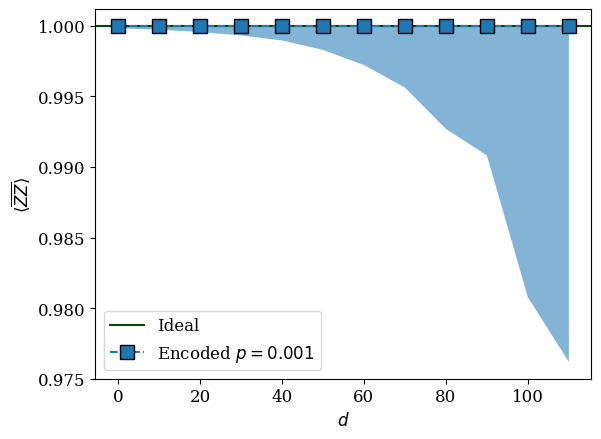

In [29]:
plt.axhline(y=1.0, color="xkcd:darkgreen", label="Ideal")

if d < 7:
    plt.plot(depths, evals_raw, "--s", ms=8, label="Physical")
    plt.fill_between(depths, evals_raw - 1 / nshots_physical, evals_raw + 1 / nshots_physical, alpha=alpha_fill)

    plt.plot(depths, evals_encoded, "--o", mec="black", ms=10, label="Encoded")
    plt.fill_between(depths, evals_encoded - stds_encoded, evals_encoded + stds_encoded, alpha=alpha_fill)

    plt.plot(depths, evals_encoded_dd,  "--o", mec="black", ms=10, label="Encoded + DD")
    plt.fill_between(depths, evals_encoded_dd - stds_encoded_dd, evals_encoded_dd + stds_encoded_dd, alpha=alpha_fill)

plt.plot(depths, evals_sim, "--s", mec="black", ms=10, label="Encoded $p = 0.001$")
plt.fill_between(depths, evals_sim - stds_sim, [min(1.0, e) for e in evals_sim + stds_sim], alpha=alpha_fill)

plt.xlabel("$d$")
plt.ylabel(r"$\langle \overline{ZZ} \rangle$")

plt.legend();


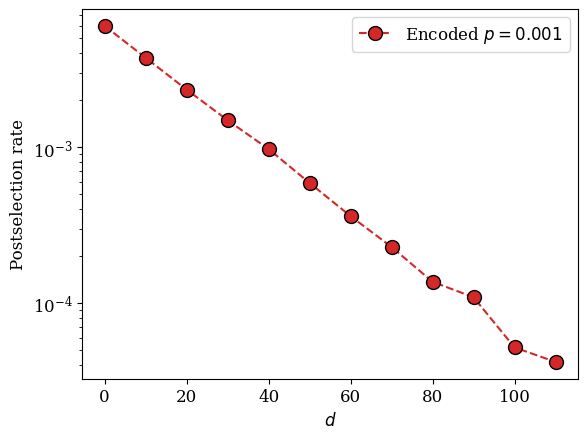

In [30]:
if d < 7:
    plt.semilogy(depths, postselection_rates, "--o", mec="black", ms=10, color="tab:orange", label="Encoded")
    plt.semilogy(depths, postselection_rates_dd, "--o", mec="black", ms=10, color="tab:green", label="Encoded + DD")
plt.semilogy(depths, postselection_rates_sim, "--o", mec="black", ms=10, color="tab:red", label="Encoded $p = 0.001$")

plt.xlabel("$d$")
plt.ylabel(r"Postselection rate")
plt.legend();

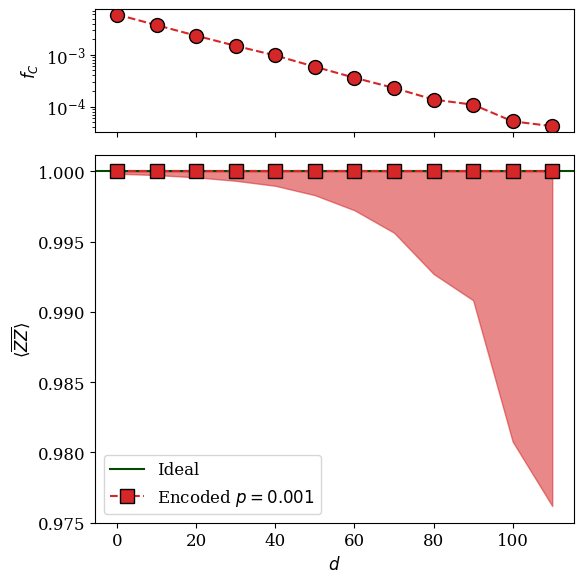

In [34]:
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={"height_ratios": [0.3334, 1]},
    figsize=(6, 6)
)

ax_bottom.axhline(y=1.0, color="xkcd:darkgreen", label="Ideal")

if d < 7:
    ax_bottom.plot(depths, evals_raw, "--s", ms=8, label="Physical")
    ax_bottom.fill_between(
        depths,
        evals_raw - 1 / nshots_physical,
        evals_raw + 1 / nshots_physical,
        alpha=alpha_fill
    )
    ax_bottom.plot(depths, evals_encoded, "--o", mec="black", ms=10, label="Encoded")
    ax_bottom.fill_between(
        depths,
        evals_encoded - stds_encoded,
        evals_encoded + stds_encoded,
        alpha=alpha_fill
    )
    ax_bottom.plot(depths, evals_encoded_dd, "--o", mec="black", ms=10, label="Encoded + DD")
    ax_bottom.fill_between(
        depths,
        evals_encoded_dd - stds_encoded_dd,
        evals_encoded_dd + stds_encoded_dd,
        alpha=alpha_fill
    )
ax_bottom.plot(depths, evals_sim, "--s", color="tab:red", mec="black", ms=10, label="Encoded $p = 0.001$")
ax_bottom.fill_between(depths, evals_sim - stds_sim, [min(1.0, e) for e in evals_sim + stds_sim], color="tab:red", alpha=alpha_fill)

ax_bottom.set_xlabel("$d$")
ax_bottom.set_ylabel(r"$\langle \overline{ZZ} \rangle$")
ax_bottom.legend()

if d < 7:
    ax_top.semilogy(depths, postselection_rates, "--o", mec="black", ms=10,
                color="tab:orange", label="Encoded")
    ax_top.semilogy(depths, postselection_rates_dd, "--o", mec="black", ms=10,
                color="tab:green", label="Encoded + DD")
ax_top.semilogy(depths, postselection_rates_sim, "--o", mec="black", ms=10, color="tab:red", label="Encoded $p = 0.001$")


ax_top.tick_params(labelbottom=False)
ax_top.set_ylabel("$f_C$")
# ax_top.legend()

plt.tight_layout()
# plt.savefig(f"tcc_d_{d}_v2.pdf");

In [ ]:
logical_state_labels = [r"$\overline{0}\overline{0}$", r"$\overline{0}\overline{1}$", r"$\overline{1}\overline{0}$", r"$\overline{1}\overline{1}$"]

## Plot circuit stats

In [68]:
from encoded.tcc import tcc_encoding

In [69]:
service = qiskit_ibm_runtime.QiskitRuntimeService(
    channel="ibm_cloud",
    token="Vwp-noJ99qjdtslYdRY6aEClfwr6PM63bP1Az7fE3015",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/8adb079e32e34c679acff94b68640033:f54da97d-7fe5-4108-9409-98a68f6ca53f::",
)
computer = service.backend("ibm_boston")
sampler = Sampler(computer)

qiskit_runtime_service._discover_account:WARNING:2026-04-26 18:47:48,405: Loading account with the given token. A saved account will not be used.


In [125]:
ds = [3, 5, 7, 9]

In [126]:
twoqs_all_to_all = []
depths_all_to_all = []

twoqs_heavy_hex = []
depths_heavy_hex = []

for d in ds:
    encode_circuit = tcc_encoding(d)
    qubits = sorted(encode_circuit.all_qubits())
    encode_circuit = cirq.H.on_each(qubits) + encode_circuit[1:]  # Remove RX gates to prepare the |+> state in favor of H.
    encode_circuit

    encoding = qiskit.QuantumCircuit.from_qasm_str(encode_circuit.to_qasm())
    twoqs_all_to_all.append(encoding.count_ops().get("cz"))
    depths_all_to_all.append(encoding.depth())

    to_run = qiskit.transpile(
        encoding, 
        backend=computer,
        routing_method="sabre",
        # scheduling_method="asap",
        optimization_level=3,
    )
    twoqs_heavy_hex.append(to_run.count_ops().get("cz"))
    depths_heavy_hex.append(to_run.depth())

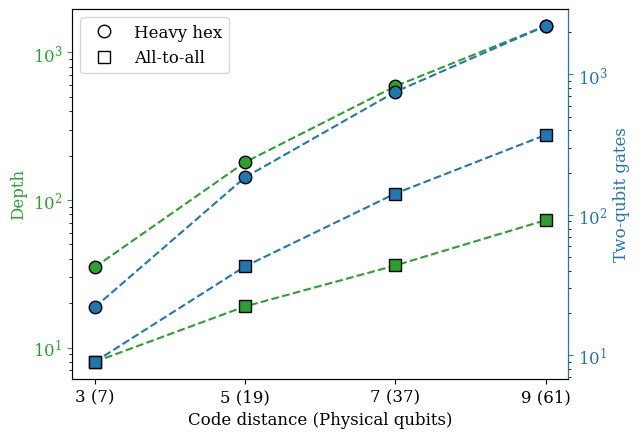

In [128]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots()

# Left axis (Depth)
ax.semilogy(ds, depths_all_to_all, "--s", ms=9, mec="black", color="tab:green")
ax.semilogy(ds, depths_heavy_hex, "--o", ms=9, mec="black", color="tab:green")

ax.set_xticks(ds)
ax.set_xticklabels(["3 (7)", "5 (19)", "7 (37)", "9 (61)"])

ax.set_xlabel("Code distance (Physical qubits)")
ax.set_ylabel("Depth", color="tab:green")
ax.tick_params(axis="y", colors="tab:green")
ax.spines["left"].set_color("tab:green")

# Right axis (Two-qubit gates)
ax_right = ax.twinx()

ax_right.semilogy(ds, twoqs_all_to_all, "--s", ms=9, mec="black", color="tab:blue")
ax_right.semilogy(ds, twoqs_heavy_hex, "--o", ms=9, mec="black", color="tab:blue")

ax_right.set_ylabel("Two-qubit gates", color="tab:blue")
ax_right.tick_params(axis="y", colors="tab:blue")
ax_right.spines["right"].set_color("tab:blue")

# Custom legend (marker shapes only)
legend_elements = [
    Line2D([0], [0], marker='o', markerfacecolor='white', markeredgecolor="black", linestyle='None', markersize=9, label='Heavy hex'),
    Line2D([0], [0], marker='s', markerfacecolor='white', markeredgecolor="black", linestyle='None', markersize=9, label='All-to-all'),
]

ax.legend(handles=legend_elements)

plt.savefig("tcc_encoding_circuits.pdf")